Code for Subsection 3.3. Newsvendor Problem

Experiment 1 configuration:
  d=5
  lambda_big=1.0
  lambda_small=4.000000e-02
  eta_base=0.001
  kappa=0.02
  holding_scale=0.05
  shortage_scale=0.1
  demand_sigma_scale=1.0
  m for tSGHMC=4.100000e-02
  condition number of A=2.441463e+01
  beta=10000000000.0, lr=0.05, gamma=1.0, r_sg=1.5, r_tu=2.0
  repeats=30, iters=5000

u_star=0.1436776805
||theta_star||=1.065081

Final expected excess risk:
  tSGHMC: 5.917582e-04
  TUSLA:  2.549422e-04
Experiment 2 rmse empirical values:
  step size=5.00e-04, rmse_TUSLA_self=1.418781e-02, rmse_tSGHMC_self=3.093299e-03
  step size=6.95e-04, rmse_TUSLA_self=1.930589e-02, rmse_tSGHMC_self=3.608187e-03
  step size=9.65e-04, rmse_TUSLA_self=2.548618e-02, rmse_tSGHMC_self=4.533599e-03
  step size=1.34e-03, rmse_TUSLA_self=3.266237e-02, rmse_tSGHMC_self=4.398904e-03
  step size=1.86e-03, rmse_TUSLA_self=4.289384e-02, rmse_tSGHMC_self=5.486265e-03
  step size=2.59e-03, rmse_TUSLA_self=5.703159e-02, rmse_tSGHMC_self=6.612474e-03
  step size=3.60e-03, rms

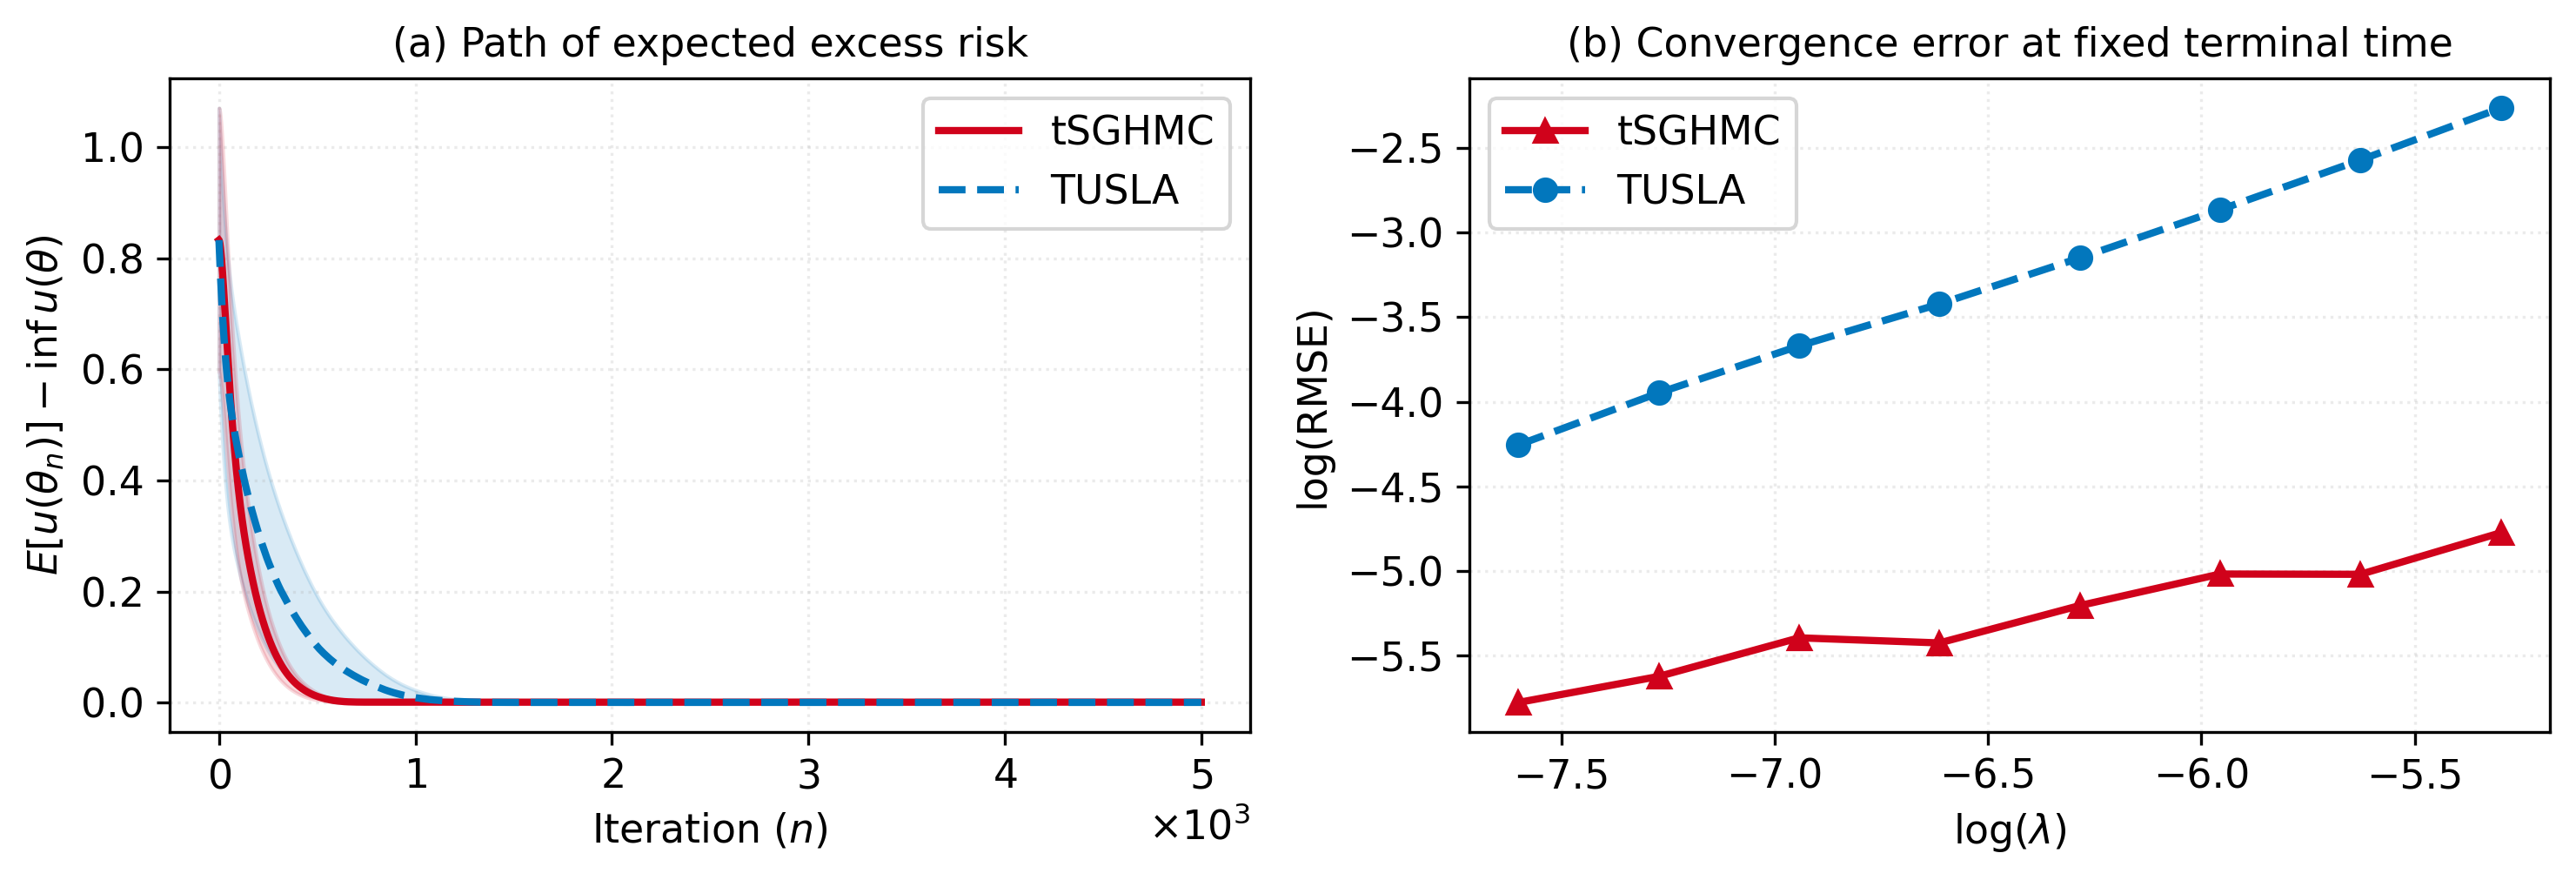

In [1]:
# ============================================================
# Example 3: High-dimensional Newsvendor Problem
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from scipy.stats import norm
from scipy.optimize import minimize
from matplotlib.ticker import ScalarFormatter

from Algorithms import TamedSGHMC, TUSLA


# ------------------------------
# Configuration
# ------------------------------
@dataclass
class Config:
    # Problem parameters
    d: int = 5
    lambda_big: float = 1.0
    eta_base: float = 1e-3
    kappa: float = 2e-2
    demand_sigma_scale: float = 1.0
    holding_scale: float = 0.05
    shortage_scale: float = 0.10
    mu_scale: float = 1.0

    # Algorithm parameters
    n_iters: int = 5000
    n_repeats: int = 30
    batch_size: int = 1
    beta: float = 1e10
    lr: float = 5e-2
    gamma: float = 1.0
    r_sg: float = 1.5
    r_tu: float = 2.0

    # Initialization
    theta0_std: float = 1.0

    # Seeds
    seed_data_base: int = 1000
    seed_sghmc_base: int = 2000
    seed_tusla_base: int = 3000
    seed_theta0_base: int = 4000


# ------------------------------
# Problem definition
# ------------------------------
class QuarticNewsvendor:

    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.d = cfg.d
        self.kappa = cfg.kappa

        lambda_small = 1.0 / (cfg.d ** 2)
        self.lambdas = np.full(cfg.d, lambda_small, dtype=float)
        self.lambdas[0] = cfg.lambda_big

        self.A = cfg.eta_base * np.eye(cfg.d) + np.diag(self.lambdas)
        self.A = 0.5 * (self.A + self.A.T)

        self.eigvals_A = cfg.eta_base + self.lambdas
        self.m = float(np.min(self.eigvals_A))

        self.mu = cfg.mu_scale * np.linspace(-1.0, 1.0, cfg.d)

        demand_eigs = cfg.demand_sigma_scale**2 * self.lambdas
        nugget = 1e-8
        self.Sigma = np.diag(demand_eigs + nugget)
        self.Sigma = 0.5 * (self.Sigma + self.Sigma.T)

        self.L = np.linalg.cholesky(self.Sigma + 1e-12 * np.eye(cfg.d))
        self.sigma_marginal = np.sqrt(np.diag(self.Sigma))

        self.h = cfg.holding_scale * np.ones(cfg.d)
        self.s = cfg.shortage_scale * np.ones(cfg.d)

    def sample_demand(self, n, rng):
        """Sample n demand vectors from N(mu, Sigma)."""
        z = rng.normal(0.0, 1.0, size=(n, self.d))
        return self.mu + z @ self.L.T

    def stochastic_gradient(self, theta, x):
        """Stochastic gradient estimator for the newsvendor objective."""
        theta = np.asarray(theta, dtype=float)
        theta_norm_sq = float(theta @ theta)

        quad_grad = self.A @ theta
        quartic_grad = self.kappa * theta_norm_sq * theta

        if x.ndim == 1:
            holding_grad = self.h * (theta > x).astype(float)
            shortage_grad = -self.s * (x > theta).astype(float)
            return quad_grad + quartic_grad + holding_grad + shortage_grad

        holding_grad_batch = self.h[None, :] * (theta[None, :] > x).astype(float)
        shortage_grad_batch = -self.s[None, :] * (x > theta[None, :]).astype(float)

        grad_batch = (
            quad_grad[None, :]
            + quartic_grad[None, :]
            + holding_grad_batch
            + shortage_grad_batch
        )

        return np.mean(grad_batch, axis=0)

    def population_risk(self, theta):
        """Analytic population risk."""
        theta = np.asarray(theta, dtype=float)

        quad = 0.5 * theta @ self.A @ theta

        theta_norm_sq = float(theta @ theta)
        quartic = 0.25 * self.kappa * theta_norm_sq**2

        z = (theta - self.mu) / self.sigma_marginal

        holding_each = (
            (theta - self.mu) * norm.cdf(z)
            + self.sigma_marginal * norm.pdf(z)
        )

        shortage_each = (
            (self.mu - theta) * (1.0 - norm.cdf(z))
            + self.sigma_marginal * norm.pdf(z)
        )

        holding = np.sum(self.h * holding_each)
        shortage = np.sum(self.s * shortage_each)

        return float(quad + quartic + holding + shortage)

    def population_gradient(self, theta):
        """Analytic population gradient."""
        theta = np.asarray(theta, dtype=float)

        theta_norm_sq = float(theta @ theta)
        z = (theta - self.mu) / self.sigma_marginal
        cdf = norm.cdf(z)
        tail_prob = 1.0 - cdf

        grad = (
            self.A @ theta
            + self.kappa * theta_norm_sq * theta
            + self.h * cdf
            - self.s * tail_prob
        )

        return grad
    
    def solve_optimum(
        self,
        lr=1e-2,
        maxiter=50000,
        beta1=0.9,
        beta2=0.999,
        eps=1e-8,
        gtol=1e-6,
    ):
        theta = self.mu.copy()
        m = np.zeros_like(theta)
        v = np.zeros_like(theta)

        for t in range(1, maxiter + 1):
            g = self.population_gradient(theta)
            grad_norm = np.linalg.norm(g)

            if grad_norm <= gtol:
                break

            m = beta1 * m + (1.0 - beta1) * g
            v = beta2 * v + (1.0 - beta2) * (g * g)

            m_hat = m / (1.0 - beta1 ** t)
            v_hat = v / (1.0 - beta2 ** t)

            theta = theta - lr * m_hat / (np.sqrt(v_hat) + eps)

        return theta

# ============================================================
# Experiment 1. Path of Expected Excess Risk for tSGHMC and TUSLA
# ============================================================

def run_expected_excess_risk(cfg: Config):
    """Run repeated simulations and return expected-excess-risk statistics."""
    problem = QuarticNewsvendor(cfg)

    theta_star = problem.solve_optimum()
    u_star = problem.population_risk(theta_star)

    all_losses_sghmc = np.zeros((cfg.n_repeats, cfg.n_iters + 1), dtype=float)
    all_losses_tusla = np.zeros((cfg.n_repeats, cfg.n_iters + 1), dtype=float)

    for rep in range(cfg.n_repeats):
        rng_data = np.random.default_rng(cfg.seed_data_base + rep)
        rng_sghmc = np.random.default_rng(cfg.seed_sghmc_base + rep)
        rng_tusla = np.random.default_rng(cfg.seed_tusla_base + rep)

        theta0 = np.random.default_rng(cfg.seed_theta0_base + rep).normal(0.0, cfg.theta0_std, size=cfg.d)

        theta_sghmc = theta0.copy()
        theta_tusla = theta0.copy()
        vol_sghmc = np.zeros(cfg.d, dtype=float)

        solver_sghmc = TamedSGHMC(H=problem.stochastic_gradient, lr=cfg.lr, gamma=cfg.gamma, beta=cfg.beta, m=problem.m, r=cfg.r_sg)
        solver_tusla = TUSLA(H=problem.stochastic_gradient, lr=cfg.lr, beta=cfg.beta, r=cfg.r_tu)

        all_losses_sghmc[rep, 0] = problem.population_risk(theta_sghmc)
        all_losses_tusla[rep, 0] = problem.population_risk(theta_tusla)

        for t in range(1, cfg.n_iters + 1):
            x_batch = problem.sample_demand(cfg.batch_size, rng_data)

            theta_sghmc, vol_sghmc = solver_sghmc.step(theta_sghmc, vol_sghmc, x_batch, rng=rng_sghmc)
            theta_tusla = solver_tusla.step(theta_tusla, x_batch, rng=rng_tusla)

            all_losses_sghmc[rep, t] = problem.population_risk(theta_sghmc)
            all_losses_tusla[rep, t] = problem.population_risk(theta_tusla)

    excess_sghmc = all_losses_sghmc - u_star
    excess_tusla = all_losses_tusla - u_star

    mean_excess_sghmc = excess_sghmc.mean(axis=0)
    mean_excess_tusla = excess_tusla.mean(axis=0)

    se_excess_sghmc = excess_sghmc.std(axis=0, ddof=1) / np.sqrt(cfg.n_repeats)
    se_excess_tusla = excess_tusla.std(axis=0, ddof=1) / np.sqrt(cfg.n_repeats)

    lb_excess_sghmc = mean_excess_sghmc - 1.96 * se_excess_sghmc
    ub_excess_sghmc = mean_excess_sghmc + 1.96 * se_excess_sghmc

    lb_excess_tusla = mean_excess_tusla - 1.96 * se_excess_tusla
    ub_excess_tusla = mean_excess_tusla + 1.96 * se_excess_tusla

    return {
        "cfg": cfg,
        "problem": problem,
        "theta_star": theta_star,
        "u_star": u_star,
        "excess_sghmc": excess_sghmc,
        "excess_tusla": excess_tusla,
        "mean_excess_sghmc": mean_excess_sghmc,
        "mean_excess_tusla": mean_excess_tusla,
        "lb_excess_sghmc": lb_excess_sghmc,
        "ub_excess_sghmc": ub_excess_sghmc,
        "lb_excess_tusla": lb_excess_tusla,
        "ub_excess_tusla": ub_excess_tusla,
    }

# ------------------------------
# Run Experiment 1
# ------------------------------
cfg = Config()
results = run_expected_excess_risk(cfg)

problem = results["problem"]

print("Experiment 1 configuration:")
print(f"  d={cfg.d}")
print(f"  lambda_big={cfg.lambda_big}")
print(f"  lambda_small={problem.lambdas[1]:.6e}")
print(f"  eta_base={cfg.eta_base}")
print(f"  kappa={cfg.kappa}")
print(f"  holding_scale={cfg.holding_scale}")
print(f"  shortage_scale={cfg.shortage_scale}")
print(f"  demand_sigma_scale={cfg.demand_sigma_scale}")
print(f"  m for tSGHMC={problem.m:.6e}")
print(f"  condition number of A={np.max(problem.eigvals_A) / np.min(problem.eigvals_A):.6e}")
print(f"  beta={cfg.beta}, lr={cfg.lr}, gamma={cfg.gamma}, r_sg={cfg.r_sg}, r_tu={cfg.r_tu}")
print(f"  repeats={cfg.n_repeats}, iters={cfg.n_iters}")
print()
print(f"u_star={results['u_star']:.10f}")
print(f"||theta_star||={np.linalg.norm(results['theta_star']):.6f}")
print()
print("Final expected excess risk:")
print(f"  tSGHMC: {results['mean_excess_sghmc'][-1]:.6e}")
print(f"  TUSLA:  {results['mean_excess_tusla'][-1]:.6e}")


# ============================================================
# Experiment 2. RMSE at Fixed Terminal Time for tSGHMC and TUSLA
# Combined figure for paper
# ============================================================

# ------------------------------
# RMSE experiment settings
# ------------------------------
n_runs = 30
T = 20.0
lambda_ref = 1e-4

h_min = 5e-4
h_max = 5e-3
lambda_list = np.exp(np.linspace(np.log(h_min), np.log(h_max), 8))

batch_size = 1

beta = 1e10
gamma = 1.0

theta0_std = 1.0
base_seed = 202500


# ------------------------------
# Problem instance
# ------------------------------
cfg_rmse = Config(
    d=5,
    lambda_big=1.0,
    eta_base=1e-3,
    kappa=2e-2,
    demand_sigma_scale=1.0,
    holding_scale=0.05,
    shortage_scale=0.10,
    mu_scale=1.0,
    n_iters=5000,
    n_repeats=30,
    batch_size=batch_size,
    beta=beta,
    lr=5e-2,
    gamma=gamma,
    r_sg=1.5,
    r_tu=2.0,
    theta0_std=theta0_std,
)

problem_rmse = QuarticNewsvendor(cfg_rmse)

# ------------------------------
# Utility functions
# ------------------------------
def make_algorithm(alg_name, lr):
    """Construct TUSLA or tSGHMC for a given step size."""
    if alg_name == "TUSLA":
        return TUSLA(
            H=problem_rmse.stochastic_gradient,
            lr=lr,
            beta=beta,
            r=cfg_rmse.r_tu,
        )

    if alg_name == "tSGHMC":
        return TamedSGHMC(
            H=problem_rmse.stochastic_gradient,
            lr=lr,
            gamma=gamma,
            beta=beta,
            m=problem_rmse.m,
            r=cfg_rmse.r_sg,
        )

    raise ValueError("alg_name must be either 'TUSLA' or 'tSGHMC'.")


def run_to_terminal_time(alg_name, theta0, lr, T, seed, batch_size=1):
    """Run one trajectory up to fixed terminal time T."""
    rng = np.random.default_rng(seed)
    n_steps = int(np.floor(T / lr))

    solver = make_algorithm(alg_name, lr)
    theta = theta0.copy()

    if alg_name == "TUSLA":
        for _ in range(n_steps):
            x_batch = problem_rmse.sample_demand(batch_size, rng)
            theta = solver.step(theta, x_batch, rng=rng)

        return theta

    if alg_name == "tSGHMC":
        vol = np.zeros_like(theta)

        for _ in range(n_steps):
            x_batch = problem_rmse.sample_demand(batch_size, rng)
            theta, vol = solver.step(theta, vol, x_batch, rng=rng)

        return theta

    raise ValueError("alg_name must be either 'TUSLA' or 'tSGHMC'.")


def one_replication_rmse(alg_name, seed, lambda_list, lambda_ref, T, batch_size=1, theta0_std=1.0):
    """Compute squared terminal errors for one independent replication."""
    rng_init = np.random.default_rng(seed)
    theta0 = rng_init.normal(loc=0.0, scale=theta0_std, size=problem_rmse.d)

    theta_ref = run_to_terminal_time(
        alg_name=alg_name,
        theta0=theta0,
        lr=lambda_ref,
        T=T,
        seed=seed + 100_000,
        batch_size=batch_size,
    )

    errors_sq = np.empty(len(lambda_list), dtype=float)

    for j, lam in enumerate(lambda_list):
        theta_lam = run_to_terminal_time(
            alg_name=alg_name,
            theta0=theta0,
            lr=lam,
            T=T,
            seed=seed + 200_000 + j,
            batch_size=batch_size,
        )

        errors_sq[j] = np.linalg.norm(theta_lam - theta_ref) ** 2

    return errors_sq

def run_rmse_experiment(alg_names, n_runs, lambda_list, lambda_ref, T, batch_size=1, theta0_std=1.0, base_seed=202500):
    """Run RMSE experiment for all algorithms."""
    results_rmse = {alg_name: [] for alg_name in alg_names}

    for alg_idx, alg_name in enumerate(alg_names):
        for run in range(n_runs):
            seed = base_seed + 10_000 * alg_idx + run
            err_sq = one_replication_rmse(
                alg_name=alg_name,
                seed=seed,
                lambda_list=lambda_list,
                lambda_ref=lambda_ref,
                T=T,
                batch_size=batch_size,
                theta0_std=theta0_std,
            )
            results_rmse[alg_name].append(err_sq)

        results_rmse[alg_name] = np.asarray(results_rmse[alg_name], dtype=float)

    return results_rmse

def summarize_rmse(results_rmse):
    """Compute MSE, standard error, and RMSE."""
    summary = {}

    for alg_name, errors_sq in results_rmse.items():
        mse = np.mean(errors_sq, axis=0)
        se = np.std(errors_sq, axis=0, ddof=1) / np.sqrt(errors_sq.shape[0])
        rmse = np.sqrt(mse)

        summary[alg_name] = {"mse": mse, "se": se, "rmse": rmse}

    return summary

# ------------------------------
# Run Experiment 2
# ------------------------------
alg_names = ["TUSLA", "tSGHMC"]

results_rmse = run_rmse_experiment(
    alg_names=alg_names,
    n_runs=n_runs,
    lambda_list=lambda_list,
    lambda_ref=lambda_ref,
    T=T,
    batch_size=batch_size,
    theta0_std=theta0_std,
    base_seed=base_seed,
)

summary_rmse = summarize_rmse(results_rmse)

rmse_tusla = summary_rmse["TUSLA"]["rmse"]
rmse_tamed = summary_rmse["tSGHMC"]["rmse"]

log_h = np.log(lambda_list)
log_rmse_tusla = np.log(rmse_tusla)
log_rmse_tamed = np.log(rmse_tamed)

slope_tusla, intercept_tusla = np.polyfit(log_h, log_rmse_tusla, deg=1)
slope_tamed, intercept_tamed = np.polyfit(log_h, log_rmse_tamed, deg=1)

trend_tusla = intercept_tusla + slope_tusla * log_h
trend_tamed = intercept_tamed + slope_tamed * log_h

print("Experiment 2 rmse empirical values:")
for h, wu, wm in zip(lambda_list, rmse_tusla, rmse_tamed):
    print(
        f"  step size={h:.2e}, "
        f"rmse_TUSLA_self={wu:.6e}, "
        f"rmse_tSGHMC_self={wm:.6e}"
    )

print()
print(f"Estimated log-log slope (TUSLA self-reference):  {slope_tusla:.6f}")
print(f"Estimated log-log slope (tSGHMC self-reference): {slope_tamed:.6f}")

# ============================================================
# Combined figure for paper: side-by-side subplots
# Left: expected excess risk from Experiment 1
# Right: terminal RMSE from Experiment 2
# ============================================================

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), dpi=300)


# ---------- Left panel: Expected excess risk ----------
ax = axes[0]

mean_sghmc_plot = np.maximum(results["mean_excess_sghmc"], 1e-4)
mean_tusla_plot = np.maximum(results["mean_excess_tusla"], 1e-4)

lb_sghmc_plot = np.maximum(results["lb_excess_sghmc"], 1e-4)
ub_sghmc_plot = np.maximum(results["ub_excess_sghmc"], 1e-4)

lb_tusla_plot = np.maximum(results["lb_excess_tusla"], 1e-4)
ub_tusla_plot = np.maximum(results["ub_excess_tusla"], 1e-4)

iters = np.arange(results["cfg"].n_iters + 1)

ax.plot(iters, mean_sghmc_plot, color="#d0021b", linewidth=2.0, label="tSGHMC", zorder=3)
ax.fill_between(iters, lb_sghmc_plot, ub_sghmc_plot, color="#d0021b", alpha=0.15, zorder=2)

ax.plot(iters, mean_tusla_plot, color="#0277bd", linewidth=2.0, linestyle="--", label="TUSLA", zorder=3)
ax.fill_between(iters, lb_tusla_plot, ub_tusla_plot, color="#0277bd", alpha=0.15, zorder=1)

ax.set_xlabel(r"Iteration $(n)$")
ax.set_ylabel(r"$E[u(\theta_n)]-\inf u(\theta)$")
ax.set_title("(a) Path of expected excess risk")
ax.grid(alpha=0.25, linestyle=":")
ax.legend(frameon=True)

sf_iter = ScalarFormatter(useMathText=True)
sf_iter.set_scientific(True)
sf_iter.set_powerlimits((0, 0))
ax.xaxis.set_major_formatter(sf_iter)
ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))


# ---------- Right panel: Terminal RMSE ----------
ax = axes[1]

ax.plot(log_h, log_rmse_tamed, color="#d0021b", marker="^", linewidth=2.0, markersize=6.0, label="tSGHMC")
ax.plot(log_h, log_rmse_tusla, color="#0277bd", marker="o", linestyle="--", linewidth=2.0, markersize=6.0, label="TUSLA")

ax.set_xlabel(r"$\log(\lambda)$")
ax.set_ylabel("log(RMSE)")
ax.set_title("(b) Convergence error at fixed terminal time")
ax.grid(alpha=0.25, linestyle=":")
ax.legend(frameon=True, loc="best")

fig.tight_layout()
plt.show()

# fig.savefig("Example3_HighNewsvendor.png", dpi=220, bbox_inches="tight")